<a href="https://colab.research.google.com/github/Maziger/Laksegate-master-thesis/blob/main/POC/tabicl_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TabICL experiment

code: https://github.com/soda-inria/tabicl?tab=readme-ov-file

paper: https://arxiv.org/abs/2602.11139

In [1]:
import os
from google.colab import userdata

user = "Maziger"
repo = "Laksegate-master-thesis"

# remove local directory if it already exists
if os.path.isdir(repo):
    !rm -rf {repo}

!git clone https://github.com/{user}/{repo}.git
%cd Laksegate-master-thesis/

!pip install -q tabicl

Cloning into 'Laksegate-master-thesis'...
remote: Enumerating objects: 356, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 356 (delta 21), reused 9 (delta 4), pack-reused 306 (from 2)
Receiving objects: 100% (356/356), 53.96 MiB | 14.05 MiB/s, done.
Resolving deltas: 100% (190/190), done.
/content/Laksegate-master-thesis
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.2/201.2 kB 16.3 MB/s eta 0:00:00


In [2]:
!pip install -q tabicl[forecast]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 94.1 MB/s eta 0:00:00


In [ ]:
# Optional
#!pip install tabicl[forecast]   # time series forecasting
#!pip install tabicl[pretrain]   # pre-training
#!pip install tabicl[all]        # everything

In [10]:
import pandas as pd
path = "POC/Forecasts_DE_DNN_LEAR_ensembles.csv"
data = pd.read_csv(path)
data = data[['Unnamed: 0', 'Real price']]
train = data[:14000]
test = data[14000:]

# Generic example

In [14]:
data

target
item_id timestamp                       
T000000 2013-03-10 00:00:00  5207.959961
        2013-03-10 00:30:00  5002.275879
        2013-03-10 01:00:00  4747.569824
        2013-03-10 01:30:00  4544.880859
        2013-03-10 02:00:00  4425.952148
...                                  ...
T000004 2015-02-28 21:30:00   360.118256
        2015-02-28 22:00:00   344.564575
        2015-02-28 22:30:00   324.242371
        2015-02-28 23:00:00   305.643646
        2015-02-28 23:30:00   293.977356

[173040 rows x 1 columns]

In [13]:
import pandas as pd
from tabicl import TabICLForecaster
from tabicl.forecast import TimeSeriesDataFrame, plot_forecast

df = pd.read_csv(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/australian_electricity_subset/test.csv",
    parse_dates=["timestamp"],
)
data = TimeSeriesDataFrame.from_data_frame(df)

prediction_length = 96
selected_items = data.item_ids[:2]
train_data, test_data = data.train_test_split(prediction_length)

context_df = train_data.reset_index()
context_df = context_df[context_df["item_id"].isin(selected_items)]
test_df = test_data.reset_index()
test_df = test_df[test_df["item_id"].isin(selected_items)]
test_df = test_df.groupby("item_id").tail(prediction_length)


GPU 0:: 100%|██████████| 2/2 [00:09<00:00,  4.96s/it]


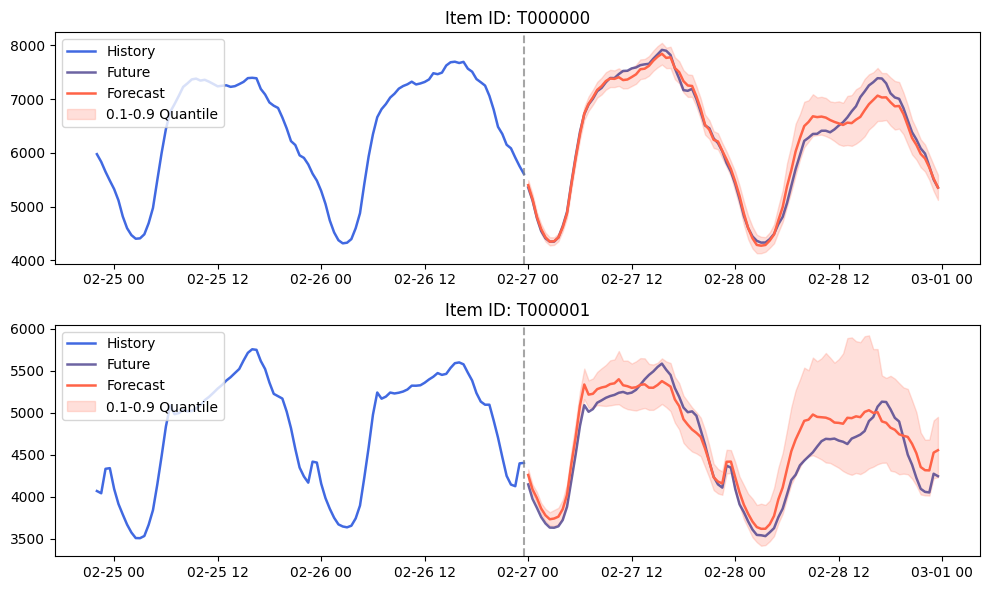

In [7]:
forecaster = TabICLForecaster(max_context_length=10240)
pred_df = forecaster.predict_df(context_df, prediction_length=prediction_length)
fig, axes = plot_forecast(context_df=context_df, pred_df=pred_df, test_df=test_df)

# Electricity price example

In [20]:
import pandas as pd
from tabicl import TabICLForecaster
from tabicl.forecast import TimeSeriesDataFrame, plot_forecast

df = pd.read_csv(
    "POC/Forecasts_DE_DNN_LEAR_ensembles.csv",
    parse_dates=["Unnamed: 0"],
)
df = df[['Unnamed: 0', 'Real price']]
df.columns = ['timestamp', 'target']
df['item_id'] = 0
data = TimeSeriesDataFrame.from_data_frame(df)

prediction_length = 96
selected_items = data.item_ids[:2]
train_data, test_data = data.train_test_split(prediction_length)

context_df = train_data.reset_index()
context_df = context_df[context_df["item_id"].isin(selected_items)]
test_df = test_data.reset_index()
test_df = test_df[test_df["item_id"].isin(selected_items)]
test_df = test_df.groupby("item_id").tail(prediction_length)

GPU 0:: 100%|██████████| 1/1 [00:05<00:00,  5.37s/it]


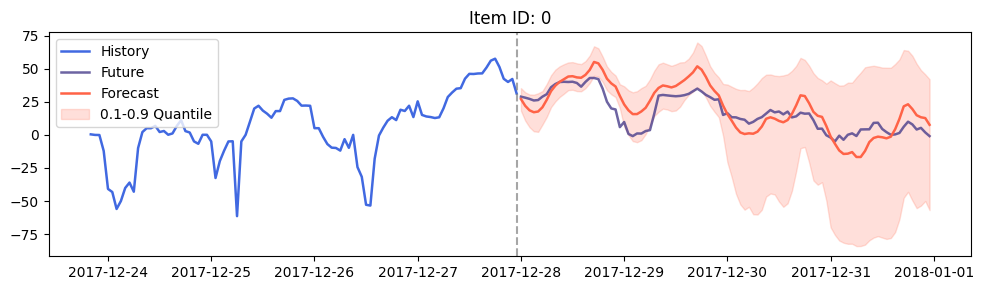

In [21]:
forecaster = TabICLForecaster(max_context_length=10240)
pred_df = forecaster.predict_df(context_df, prediction_length=prediction_length)
fig, axes = plot_forecast(context_df=context_df, pred_df=pred_df, test_df=test_df)